In [5]:
from langchain.chat_models import init_chat_model

model = init_chat_model("google_genai:gemini-3-flash-preview")

In [22]:
from langgraph.graph.message import add_messages
from typing import Annotated
from pydantic import BaseModel
from langchain_core.messages import AIMessage,HumanMessage,BaseMessage
from langchain.tools import tool
from langgraph.graph import StateGraph,END,START

class agentState(BaseModel):
    messages:Annotated[list[BaseMessage],add_messages]




In [23]:
@tool
def calculate(expression:str)->str:
    """Calcute any expression"""
    return str(eval(expression))

@tool
def weather(state:str)->str:
    """get weather of any state"""
    return f"weather of {state} is sunny"

tools = [calculate,weather]

In [24]:
from langgraph.prebuilt import ToolNode
model_with_tools = model.bind_tools(tools)
tool_node = ToolNode(tools)

In [25]:
def agent_node(state:agentState):
    res = model_with_tools.invoke(state.messages)
    return {"messages":[res]}

def route_after_agent(state:agentState):
    last = state.messages[-1]

    if last.tool_calls:
        return "tools"
    
    return "final"

def final(state:agentState):
    return {"messages":state.messages}
    

In [26]:
graph = StateGraph(agentState)

graph.add_node("agent",agent_node)
graph.add_node("tools",tool_node)
graph.add_node("final",final)

graph.add_edge(START,"agent")

graph.add_conditional_edges(
    "agent",
    route_after_agent,
    {
        "tools":"tools",
        "final":"final"
    }
)

graph.add_edge("tools","agent")
graph.add_edge("agent","final")

agent_graph = graph.compile()



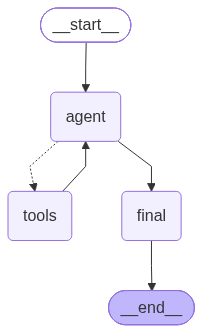

In [27]:
agent_graph

In [28]:
agent_graph.invoke(agentState(
    messages=[HumanMessage(content="claculate 2*2/2 and get weather of up")]
))

{'messages': [HumanMessage(content='claculate 2*2/2 and get weather of up', additional_kwargs={}, response_metadata={}, id='5db4ba28-679c-4358-87aa-d02334ceab9d'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'weather', 'arguments': '{"state": "up"}'}, '__gemini_function_call_thought_signatures__': {'call_1968504': 'EtUDCtIDARFNMg9y/zjc+4ivLFVgdQD/bKA3artQ1i5Pp9WsezKQJrzeuiItSQBlWcwb6z4GRzHTt3iCoXNOMbLcbUlj24wuPiJv5nvKN6QeeNvSxUUoHhkSOKpgA2CSJYI3DDyUMnVabhH1wtwmdDtTEtzZuEX7657V2tIzzs/36oBW+jF55JZK9XpewIU9Wx7FpiAXvCiEjhqePEaNUlxKb6j9JpocMPCiQd68GLtIvMB5YEoMbOny1esgazGlMrXels3qqBo4qTBXZQe9flUH6RHV0v7tFcerCwx3BjDyPOanWvwqgXJw9o81ND/wxfyzTrTf3A8n4aaXPlEvuuZSEWzbH7NdEJJOpIt76IkRQvXtDYKmNko00uHBpi55OMVdUyvRtAzpFfKAORRc3VMi2OikBqnv89Vub7CDL1mBUp7+OwCVaF8vMyPS6m5KVBg/BltkeJT/+xCr5N6tB+jvIalAGdBkHDZiVVl4qkOpzqPy7P1qhAPSIgE/XZZIGPtW4a05HgyNTIzAIkDfqMBxwH5k7iwXPl7kgUgrtEjnnaNfnjq+IIy8UGXZk/W4uUBRNPeV9CL39enm+5bm86RZj8a2+8oWes4h8SBNuMSx9PlLJTDIcQ=='}}, response_metadata={'f